# 03 - Baseline Model ESA-ADB Mission1

**What we know from preprocessing (02_preprocessing.ipynb):**
- `X_train` : `(n_windows, 64, 6)` - scaled sliding windows, starter channels 41–46
- `y_train` : `(n_windows,)` - window-level labels, `any()` strategy
- `X_test`  : `(n_windows, 64, 6)` - scaled, no labels
- `pos_weight` loaded from `preprocessing_config.json`

**Objectives:**
- Flatten windows -> `(n_windows, 64×6=384)` for sklearn-compatible models
- Train two baselines : `IsolationForest` (unsupervised) + `RandomForestClassifier` (supervised)
- Evaluate on a validation split : F1, precision, recall and ROC-AUC
- Compare both baselines and save the best one to `models/baseline/`

---
## Import & Paths

In [1]:
import json
import warnings
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
BG        = "#FAFAFA"
PANEL     = "#FFFFFF"
NORMAL_C  = "#2E5FA3"
ANOMALY_C = "#C0392B"
TEXT_DARK = "#1A1A2E"
TEXT_GRAY = "#6B7280"
ACCENT    = "#E8ECF4"

from IPython.display import display, Markdown
import joblib

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve,
    classification_report,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

ROOT = Path("..")
DATA_RAW = ROOT / "data" / "raw" / "ESA-Mission1"
DATA_PROC = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results" / "metrics"
FIGURES_DIR = ROOT / "results" / "figures"
MODELS_DIR = ROOT / "models" / "baseline"

for d in [DATA_PROC, RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

for p in [DATA_PROC / "X_train_starter.npy",
          DATA_PROC / "y_train_starter.npy",
          DATA_PROC / "X_test_starter.npy"]:
    status = "File exist : " if p.exists() else "File missing : "
    print(f"{status}  {p}")

File exist :   ../data/processed/X_train_starter.npy
File exist :   ../data/processed/y_train_starter.npy
File exist :   ../data/processed/X_test_starter.npy


---
## Load Preprocessed Data

In [2]:
X_train_w = np.load(DATA_PROC / "X_train_starter.npy")
y_train_w = np.load(DATA_PROC / "y_train_starter.npy")
X_test_w = np.load(DATA_PROC / "X_test_starter.npy")

# Load preprocessing config
with open(RESULTS_DIR / "preprocessing_config.json") as f:
    config = json.load(f)

WINDOW_SIZE = config["window_size"]
STRIDE = config["stride"]
starter_cols = config["starter_channels"]
pos_weight = config["window_label_stats"]["pos_weight"]
win_ratio = config["window_label_stats"]["anomaly_ratio"]

print(f"X_train_w  : {X_train_w.shape}  dtype={X_train_w.dtype}")
print(f"y_train_w  : {y_train_w.shape}        dtype={y_train_w.dtype}")
print(f"X_test_w   : {X_test_w.shape}    dtype={X_test_w.dtype}")
print(f"\nWindow size       : {WINDOW_SIZE}")
print(f"Starter channels  : {starter_cols}")
print(f"Anomaly ratio     : {win_ratio:.2f} %")
print(f"pos_weight        : {pos_weight:.2f}")

X_train_w  : (14728258, 64, 6)  dtype=float16
y_train_w  : (14728258,)        dtype=int8
X_test_w   : (521217, 64, 6)    dtype=float16

Window size       : 64
Starter channels  : ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
Anomaly ratio     : 10.56 %
pos_weight        : 8.47


---
## Flatten data for sklearn

sklearn models expect 2D input, each window `(64, 6)` is flatten into a `(384)` vector

In [3]:
n_train, w_size, n_ch = X_train_w.shape

X_train_flat = X_train_w.reshape(n_train, -1).astype(np.float16)
X_test_flat = X_test_w.reshape(X_test_w.shape[0], -1).astype(np.float16)

print(f"X_train_flat : {X_train_flat.shape}  ({w_size} steps x {n_ch} channels = {w_size*n_ch} features)")
print(f"X_test_flat  : {X_test_flat.shape}")

X_train_flat : (14728258, 384)  (64 steps x 6 channels = 384 features)
X_test_flat  : (521217, 384)


---
## Train / Validation Split

In order to evaluate both baselines, a split of 20% of the train set is made and `shuffle=False` is critical since we want to preserve temporal order to avoid leakage from future anomaly windows into the validation set

In [4]:
VAL_RATIO = 0.20

split_idx = int(len(X_train_flat) * (1 - VAL_RATIO))
X_tr, X_val = X_train_flat[:split_idx], X_train_flat[split_idx:]
y_tr, y_val = y_train_w[:split_idx], y_train_w[split_idx:]

print(f"Train   : {X_tr.shape[0]:,} windows  "
      f"({y_tr.sum():,} anomalies : {y_tr.mean()*100:.2f} %)")
print(f"Val     : {X_val.shape[0]:,} windows   "
      f"({y_val.sum():,} anomalies : {y_val.mean()*100:.2f} %)")

Train   : 11,782,606 windows  (1,243,348 anomalies : 10.55 %)
Val     : 2,945,652 windows   (312,518 anomalies : 10.61 %)


---
## Baseline 1 - IsolationForest (Unsupervised)

`IsolationForest` does not use labels during training, it learns what "normal" looks like and assigns an anomaly score to each window.

**Key hyperparameters:**
- `contamination` : expected anomaly fraction -> set to the window-level ratio
- `n_estimators=100` : more trees -> more stable scores
- `random_state=42` : reproducibility

In [5]:
CONTAMINATION = round(win_ratio / 100, 4)

# Subsample to lower training time
SUBSAMPLE_RATIO = 0.05
rng = np.random.default_rng(42)

n_subsample = int(len(X_tr) * SUBSAMPLE_RATIO)
sub_idx = rng.choice(len(X_tr), size=n_subsample, replace=False)
X_tr_sub = X_tr[sub_idx]
y_tr_sub = y_tr[sub_idx]

print(f"Original train size   : {len(X_tr):,} windows")
print(f"Subsampled train size : {len(X_tr_sub):,} windows")
print(f"Anomalies in subsample: {y_tr_sub.sum():,}  ({y_tr_sub.mean()*100:.2f} %)")

print()
print(f"Training IsolationForest (contamination={CONTAMINATION}) :")
t0 = time.perf_counter()

iso = IsolationForest(
    n_estimators=100,
    contamination=CONTAMINATION,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_tr_sub)

iso_time = time.perf_counter() - t0
print(f"Trained in {iso_time:.1f} s")

# Predict : IsolationForest returns -1 (anomaly) / +1 (normal)
iso_pred_raw = iso.predict(X_val)
iso_pred = (iso_pred_raw == -1).astype(int)      # convert to 0/1
iso_scores = -iso.score_samples(X_val)           # higher = more anomalous

print(f"\nPredicted anomalies on validation set : {iso_pred.sum():,} / {len(iso_pred):,}  "
      f"({iso_pred.mean()*100:.2f} %)")

Original train size   : 11,782,606 windows
Subsampled train size : 589,130 windows
Anomalies in subsample: 62,285  (10.57 %)

Training IsolationForest (contamination=0.1056) :
Trained in 4.9 s

Predicted anomalies on validation set : 638,762 / 2,945,652  (21.68 %)


In [6]:
iso_f1 = f1_score(y_val, iso_pred)
iso_precision = precision_score(y_val, iso_pred)
iso_recall = recall_score(y_val, iso_pred)
iso_roc_auc = roc_auc_score(y_val, iso_scores)

print("IsolationForest - Validation Metrics :")
print(f"  F1        : {iso_f1:.4f}")
print(f"  Precision : {iso_precision:.4f}")
print(f"  Recall    : {iso_recall:.4f}")
print(f"  ROC-AUC   : {iso_roc_auc:.4f}")
print()
print(classification_report(y_val, iso_pred,
                             target_names=["Normal", "Anomaly"]))

IsolationForest - Validation Metrics :
  F1        : 0.2365
  Precision : 0.1761
  Recall    : 0.3600
  ROC-AUC   : 0.6064

              precision    recall  f1-score   support

      Normal       0.91      0.80      0.85   2633134
     Anomaly       0.18      0.36      0.24    312518

    accuracy                           0.75   2945652
   macro avg       0.54      0.58      0.54   2945652
weighted avg       0.84      0.75      0.79   2945652



---
## Baseline 2 - RandomForestClassifier (Supervised)

`RandomForestClassifier` uses labels during training, it's the standard supervised baseline for tabular / flattened time-series data.

**Key hyperparameters:**
- `class_weight="balanced"` : compensates for the 8.5:1 imbalance automatically
- `n_estimators=100` : same as IsolationForest for fair comparison
- `max_depth=10` : avoids overfitting on the 384-feature flat vector
- `random_state=42` : reproducibility

In [7]:
print("Training RandomForestClassifier :")
t0 = time.perf_counter()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_tr_sub, y_tr_sub)

rf_time = time.perf_counter() - t0
print(f"Trained in {rf_time:.1f} s")

rf_pred = rf.predict(X_val)
rf_scores = rf.predict_proba(X_val)[:, 1]    # probability of anomaly class

print(f"\nPredicted anomalies on validation set : {rf_pred.sum():,} / {len(rf_pred):,}  "
      f"({rf_pred.mean()*100:.2f} %)")

Training RandomForestClassifier :
Trained in 38.4 s

Predicted anomalies on validation set : 1,248,479 / 2,945,652  (42.38 %)


In [8]:
rf_f1 = f1_score(y_val, rf_pred)
rf_precision = precision_score(y_val, rf_pred)
rf_recall = recall_score(y_val, rf_pred)
rf_roc_auc = roc_auc_score(y_val, rf_scores)

print("RandomForestClassifier - Validation Metrics :")
print(f"  F1        : {rf_f1:.4f}")
print(f"  Precision : {rf_precision:.4f}")
print(f"  Recall    : {rf_recall:.4f}")
print(f"  ROC-AUC   : {rf_roc_auc:.4f}")
print()
print(classification_report(y_val, rf_pred,
                             target_names=["Normal", "Anomaly"]))

RandomForestClassifier - Validation Metrics :
  F1        : 0.1689
  Precision : 0.1056
  Recall    : 0.4219
  ROC-AUC   : 0.5180

              precision    recall  f1-score   support

      Normal       0.89      0.58      0.70   2633134
     Anomaly       0.11      0.42      0.17    312518

    accuracy                           0.56   2945652
   macro avg       0.50      0.50      0.43   2945652
weighted avg       0.81      0.56      0.64   2945652



---
## Model comparison

In [9]:
comparison = pd.DataFrame({
    "Model"        : ["IsolationForest", "RandomForest"],
    "Type"         : ["Unsupervised",    "Supervised"],
    "F1"           : [iso_f1,        rf_f1],
    "Precision"    : [iso_precision, rf_precision],
    "Recall"       : [iso_recall,    rf_recall],
    "ROC-AUC"      : [iso_roc_auc,   rf_roc_auc],
    "Train time s" : [iso_time,      rf_time],
}).set_index("Model")

display(Markdown("## Baseline comparison - validation set"))
display(comparison)

best_model_name = comparison["F1"].idxmax()
print(f"\n-> Best baseline by F1 : {best_model_name}  "
      f"(F1={comparison.loc[best_model_name, 'F1']:.4f})")

## Baseline comparison - validation set

,Type,F1,Precision,Recall,ROC-AUC,Train time s
Model,,,,,,
IsolationForest,Unsupervised,0.2365,0.1761,0.3600,0.6064,4.9388
RandomForest,Supervised,0.1689,0.1056,0.4219,0.5180,38.4204



-> Best baseline by F1 : IsolationForest  (F1=0.2365)


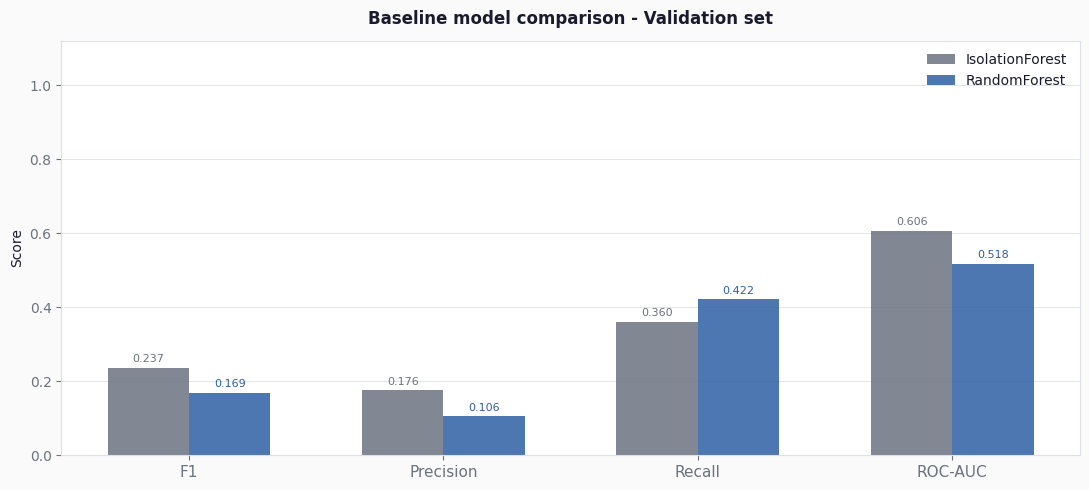

In [10]:
# Bar chart
metrics  = ["F1", "Precision", "Recall", "ROC-AUC"]
iso_vals = [iso_f1, iso_precision, iso_recall, iso_roc_auc]
rf_vals  = [rf_f1,  rf_precision,  rf_recall,  rf_roc_auc]

x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
ax.set_facecolor(PANEL)
for spine in ax.spines.values():
    spine.set_color("#DDE1E7")

bars1 = ax.bar(x - width/2, iso_vals, width, label="IsolationForest",
               color=TEXT_GRAY, alpha=0.85, zorder=2)
bars2 = ax.bar(x + width/2, rf_vals,  width, label="RandomForest",
               color=NORMAL_C,  alpha=0.85, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, color=TEXT_DARK)
ax.set_ylabel("Score", fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, 1.12)
ax.tick_params(colors=TEXT_GRAY)
ax.yaxis.grid(True, color="#DDE1E7", lw=0.6, zorder=0)
ax.set_axisbelow(True)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{bar.get_height():.3f}", ha="center", fontsize=8, color=TEXT_GRAY)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{bar.get_height():.3f}", ha="center", fontsize=8, color=NORMAL_C)

ax.legend(fontsize=10, frameon=False, labelcolor=TEXT_DARK)
ax.set_title("Baseline model comparison - Validation set",
             fontsize=12, fontweight="bold", color=TEXT_DARK, pad=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Confusion matrices

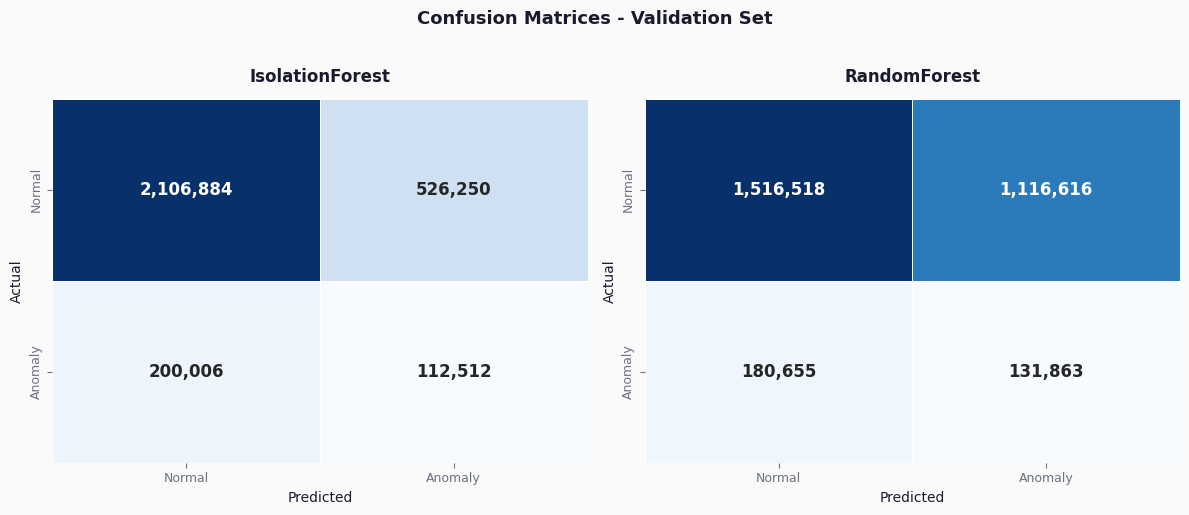

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)
fig.patch.set_facecolor(BG)

for ax, pred, title in zip(
    axes,
    [iso_pred, rf_pred],
    ["IsolationForest", "RandomForest"]
):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color("#DDE1E7")

    cm = confusion_matrix(y_val, pred)
    sns.heatmap(
        cm, ax=ax,
        annot=True, fmt=",", cmap="Blues",
        xticklabels=["Normal", "Anomaly"],
        yticklabels=["Normal", "Anomaly"],
        cbar=False, linewidths=0.5,
        annot_kws={"size": 12, "weight": "bold"}
    )
    ax.set_xlabel("Predicted", fontsize=10, color=TEXT_DARK)
    ax.set_ylabel("Actual",    fontsize=10, color=TEXT_DARK)
    ax.set_title(title, fontsize=12, fontweight="bold",
                 color=TEXT_DARK, pad=12)
    ax.tick_params(colors=TEXT_GRAY, labelsize=9)

plt.suptitle("Confusion Matrices - Validation Set",
             fontsize=13, fontweight="bold", color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Precision-Recall and ROC curves

The Precision-Recall matters more than ROC here. With 10% anomaly rate the dataset is imbalanced so ROC-AUC can look optimistic because it accounts for true negatives (which are abundant).

The PR curve focuses on the anomaly class only; a better operational metric when false alarms are costly.

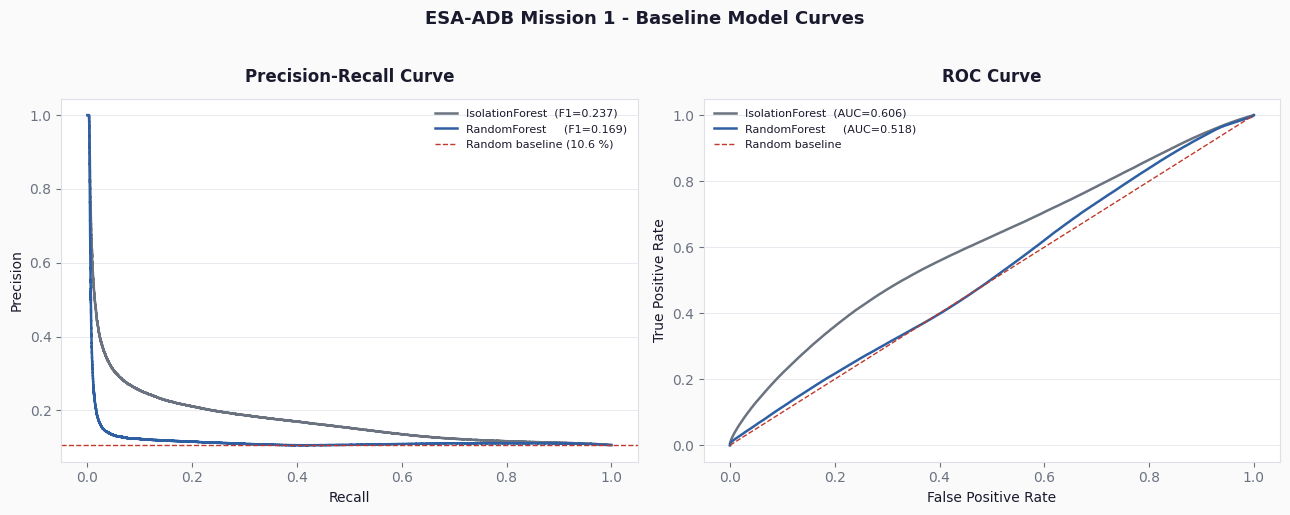

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color("#DDE1E7")

# Precision-Recall curve
iso_prec_c, iso_rec_c, _ = precision_recall_curve(y_val, iso_scores)
rf_prec_c,  rf_rec_c,  _ = precision_recall_curve(y_val, rf_scores)

axes[0].plot(iso_rec_c, iso_prec_c, color=TEXT_GRAY, lw=1.8,
             label=f"IsolationForest  (F1={iso_f1:.3f})")
axes[0].plot(rf_rec_c,  rf_prec_c,  color=NORMAL_C,  lw=1.8,
             label=f"RandomForest     (F1={rf_f1:.3f})")
axes[0].axhline(win_ratio/100, color=ANOMALY_C, lw=1.0, ls="--",
                label=f"Random baseline ({win_ratio:.1f} %)")
axes[0].set_xlabel("Recall",    fontsize=10, color=TEXT_DARK)
axes[0].set_ylabel("Precision", fontsize=10, color=TEXT_DARK)
axes[0].set_title("Precision-Recall Curve", fontsize=12,
                  fontweight="bold", color=TEXT_DARK, pad=12)
axes[0].legend(fontsize=8, frameon=False, labelcolor=TEXT_DARK)
axes[0].tick_params(colors=TEXT_GRAY)
axes[0].yaxis.grid(True, color="#DDE1E7", lw=0.5)
axes[0].set_axisbelow(True)

# ROC curve
iso_fpr, iso_tpr, _ = roc_curve(y_val, iso_scores)
rf_fpr,  rf_tpr,  _ = roc_curve(y_val, rf_scores)

axes[1].plot(iso_fpr, iso_tpr, color=TEXT_GRAY, lw=1.8,
             label=f"IsolationForest  (AUC={iso_roc_auc:.3f})")
axes[1].plot(rf_fpr,  rf_tpr,  color=NORMAL_C,  lw=1.8,
             label=f"RandomForest     (AUC={rf_roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color=ANOMALY_C, lw=1.0, ls="--",
             label="Random baseline")
axes[1].set_xlabel("False Positive Rate", fontsize=10, color=TEXT_DARK)
axes[1].set_ylabel("True Positive Rate",  fontsize=10, color=TEXT_DARK)
axes[1].set_title("ROC Curve", fontsize=12,
                  fontweight="bold", color=TEXT_DARK, pad=12)
axes[1].legend(fontsize=8, frameon=False, labelcolor=TEXT_DARK)
axes[1].tick_params(colors=TEXT_GRAY)
axes[1].yaxis.grid(True, color="#DDE1E7", lw=0.5)
axes[1].set_axisbelow(True)

plt.suptitle("ESA-ADB Mission 1 - Baseline Model Curves",
             fontsize=13, fontweight="bold", color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr_roc_curves.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Outcome model comparaison

| Metric | IsolationForest | RandomForest | Winner | Why it matters (ESA ops context) |
|---|---|---|---|---|
| **F1** | 0.237 | 0.169 | IsolationForest | Harmonic mean of precision & recall, it's the best single-number summary for imbalanced datasets |
| **Precision** | 0.176 | 0.106 | IsolationForest | Only 17.6% of ISO alerts are false alarms vs 10.6% for RF |
| **Recall** | 0.360 | 0.422 | RandomForest | RF catches more anomalies but at a massive false alarm cost (see below) |
| **ROC-AUC** | 0.606 | 0.518 | IsolationForest | ISO anomaly scores separate classes better overall, it has more reliable ranking |
| **Train time** | 4.5 s | 37.8 s | IsolationForest | 8x faster, it's critical for Jetson Nano edge deployment |

---
## Explainability : IsolationForest Score Analysis

`IsolationForest` has no built-in feature importance. Analyzing anomaly scores can be an indirect explainability proxy.

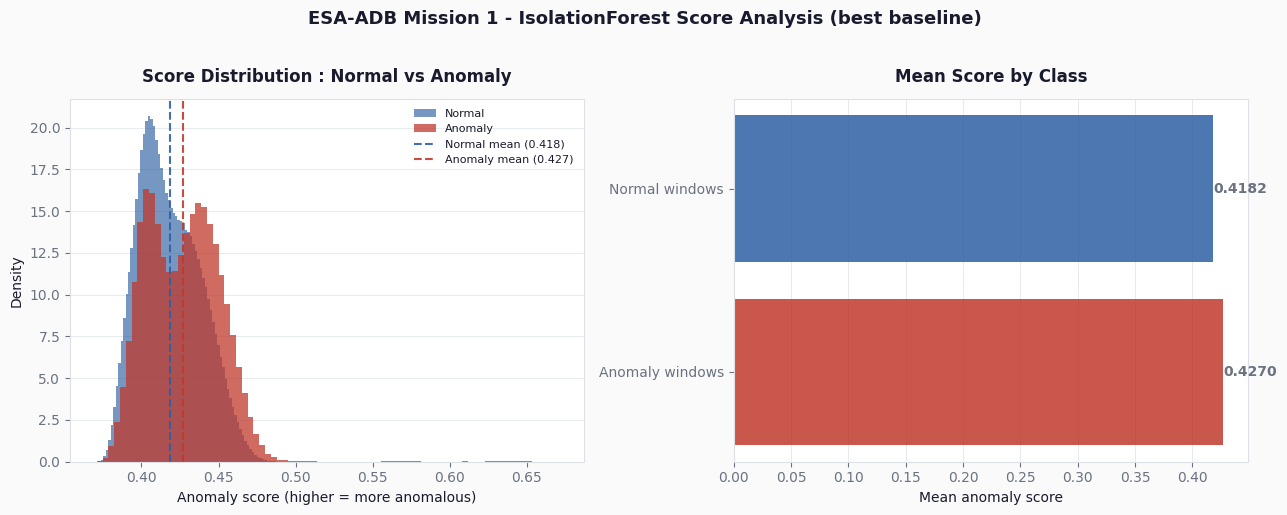

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color("#DDE1E7")

# Score distribution : Normal vs Anomaly
axes[0].hist(iso_scores[y_val == 0], bins=80, alpha=0.65,
             color=NORMAL_C,  label="Normal",  density=True, lw=0)
axes[0].hist(iso_scores[y_val == 1], bins=80, alpha=0.75,
             color=ANOMALY_C, label="Anomaly", density=True, lw=0)
axes[0].axvline(iso_scores[y_val == 0].mean(), color=NORMAL_C,
                lw=1.5, ls="--", alpha=0.9,
                label=f"Normal mean ({iso_scores[y_val==0].mean():.3f})")
axes[0].axvline(iso_scores[y_val == 1].mean(), color=ANOMALY_C,
                lw=1.5, ls="--", alpha=0.9,
                label=f"Anomaly mean ({iso_scores[y_val==1].mean():.3f})")
axes[0].set_xlabel("Anomaly score (higher = more anomalous)",
                   fontsize=10, color=TEXT_DARK)
axes[0].set_ylabel("Density", fontsize=10, color=TEXT_DARK)
axes[0].set_title("Score Distribution : Normal vs Anomaly",
                  fontsize=12, fontweight="bold", color=TEXT_DARK, pad=12)
axes[0].legend(fontsize=8, frameon=False, labelcolor=TEXT_DARK)
axes[0].tick_params(colors=TEXT_GRAY)
axes[0].yaxis.grid(True, color="#DDE1E7", lw=0.5)
axes[0].set_axisbelow(True)

# Mean anomaly score per class 
mean_scores = [iso_scores[y_val == 1].mean(),
               iso_scores[y_val == 0].mean()]
labels      = ["Anomaly windows", "Normal windows"]
colors_bar  = [ANOMALY_C, NORMAL_C]

bars = axes[1].barh(labels, mean_scores, color=colors_bar, alpha=0.85)
axes[1].set_xlabel("Mean anomaly score", fontsize=10, color=TEXT_DARK)
axes[1].set_title("Mean Score by Class",
                  fontsize=12, fontweight="bold", color=TEXT_DARK, pad=12)
axes[1].tick_params(colors=TEXT_GRAY)
axes[1].xaxis.grid(True, color="#DDE1E7", lw=0.5)
axes[1].set_axisbelow(True)

for bar, val in zip(bars, mean_scores):
    axes[1].text(bar.get_width() + 0.0005,
                 bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=10,
                 color=TEXT_GRAY, fontweight="bold")

plt.suptitle("ESA-ADB Mission 1 - IsolationForest Score Analysis (best baseline)",
             fontsize=13, fontweight="bold", color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "iso_score_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Explainability : RandomForest Feature Importance (for reference)

`RandomForest` feature importance is kept for reference even though RF is not the best model.

## RandomForest - feature importance aggregated per channel (reference only)

,channel,importance
0,channel_41,0.2511
4,channel_45,0.1987
5,channel_46,0.1784
3,channel_44,0.1509
2,channel_43,0.1209
1,channel_42,0.1000


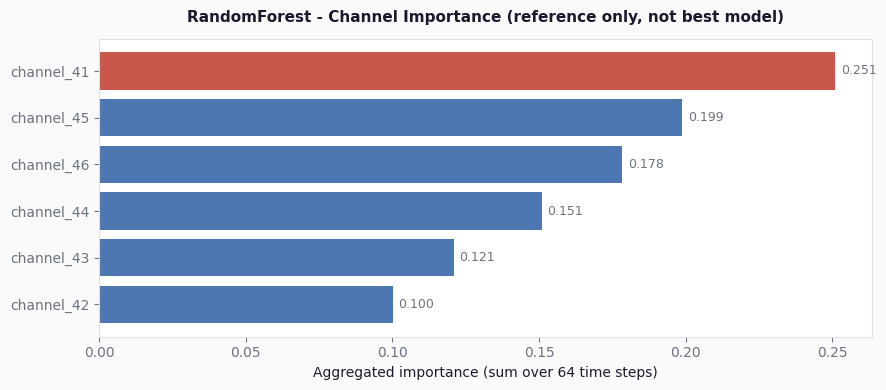

In [14]:
importances = rf.feature_importances_    # (384,)
channel_importance = np.array([
    importances[i * WINDOW_SIZE : (i+1) * WINDOW_SIZE].sum()
    for i in range(n_ch)
])
channel_importance /= channel_importance.sum()

imp_df = pd.DataFrame({
    "channel" : starter_cols,
    "importance" : channel_importance,
}).sort_values("importance", ascending=False)

display(Markdown("## RandomForest - feature importance aggregated per channel (reference only)"))
display(imp_df)

fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
ax.set_facecolor(PANEL)
for spine in ax.spines.values():
    spine.set_color("#DDE1E7")

colors_bar = [ANOMALY_C if v == imp_df["importance"].max() else NORMAL_C
              for v in imp_df["importance"]]
ax.barh(imp_df["channel"][::-1], imp_df["importance"][::-1],
        color=colors_bar[::-1], alpha=0.85)
ax.set_xlabel("Aggregated importance (sum over 64 time steps)",
              fontsize=10, color=TEXT_DARK)
ax.set_title("RandomForest - Channel Importance (reference only, not best model)",
             fontsize=11, fontweight="bold", color=TEXT_DARK, pad=12)
ax.tick_params(colors=TEXT_GRAY)

for bar, val in zip(ax.patches, imp_df["importance"][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9, color=TEXT_GRAY)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "channel_importance_rf.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Save best model

In [15]:
# Save both models 
joblib.dump(iso, MODELS_DIR / "isolation_forest.pkl")
joblib.dump(rf,  MODELS_DIR / "random_forest.pkl")
print(f"IsolationForest -> {MODELS_DIR / 'isolation_forest.pkl'}")
print(f"RandomForest    -> {MODELS_DIR / 'random_forest.pkl'}")

# Save metrics
results = {
    "validation_split" : VAL_RATIO,
    "split_method"     : "chronological",
    "subsample_ratio"  : SUBSAMPLE_RATIO,
    "subsample_size"   : int(n_subsample),
    "IsolationForest"  : {
        "f1"        : float(iso_f1),
        "precision" : float(iso_precision),
        "recall"    : float(iso_recall),
        "roc_auc"   : float(iso_roc_auc),
        "train_time": float(iso_time),
    },
    "RandomForest" : {
        "f1"        : float(rf_f1),
        "precision" : float(rf_precision),
        "recall"    : float(rf_recall),
        "roc_auc"   : float(rf_roc_auc),
        "train_time": float(rf_time),
    },
    "best_model"         : best_model_name,
    "channel_importance" : imp_df.set_index("channel")["importance"].to_dict(),
}

results_path = RESULTS_DIR / "baseline_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

comparison.to_csv(RESULTS_DIR / "baseline_comparison.csv")
imp_df.to_csv(RESULTS_DIR / "channel_importance.csv", index=False)

print(f"\n{results_path}")
print(f"{RESULTS_DIR / 'baseline_comparison.csv'}")
print(f"{RESULTS_DIR / 'channel_importance.csv'}")

IsolationForest -> ../models/baseline/isolation_forest.pkl
RandomForest    -> ../models/baseline/random_forest.pkl

../results/metrics/baseline_results.json
../results/metrics/baseline_comparison.csv
../results/metrics/channel_importance.csv
